# Why multi-configurational? Watch a chemical bond break

Almost every workhorse method in quantum chemistry — Hartree–Fock, MP2, coupled cluster — starts from **one** electronic configuration (a single Slater determinant) and assumes that configuration dominates. That assumption is excellent for most molecules near equilibrium. It **falls apart** when bonds stretch and break, or whenever several configurations become comparably important. This is the regime of **strong (static) correlation**, and it is where **multi-configurational** methods stop being optional.

We'll make this concrete by pulling apart the triple bond of **carbon monoxide, CO**. Using [`qdk-chemistry`](https://github.com/microsoft/qdk-chemistry) through one consistent interface, we will:

1. Walk the C–O bond from its equilibrium length out to full dissociation
2. At each point run the single-reference trio — **Hartree–Fock, MP2, CCSD**
3. Compare against a **multi-configurational CASCI** solver
4. Watch the single-reference methods **break down** as the bond breaks (CCSD even stops converging), while CASCI stays smooth and physical
5. Diagnose *why*, by looking straight at the wavefunction's configurations

> Setup: `pip install 'qdk-chemistry[all]'` (plus `matplotlib` for the plots).

In [1]:
import contextlib
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qdk_chemistry.utils import Logger
from qdk_chemistry.data import Structure, Ansatz
from qdk_chemistry.algorithms import create

# Quiet logging for a clean demo
Logger.set_global_level(Logger.LogLevel.off)

# Keep the PySCF backend (used by the CCSD calculator) quiet so output stays clean
import pyscf  # noqa: E402
pyscf.gto.Mole.verbose = 0

HARTREE2KCAL = 627.509  # kcal/mol per Hartree
BASIS = "cc-pvdz"
ACTIVE_ELECTRONS, ACTIVE_ORBITALS = 10, 8  # full valence active space of CO: CAS(10,8)


def co_geometry(bond_length: float) -> Structure:
    """Build a CO molecule with the given C-O bond length (in Angstrom)."""
    xyz = f"2\nCO at {bond_length:.3f} Angstrom\nC 0.0 0.0 0.0\nO 0.0 0.0 {bond_length:.6f}\n"
    return Structure.from_xyz(xyz)


@contextlib.contextmanager
def _silence_backends():
    """Silence chatter from compiled backends (e.g. PySCF) at both the
    file-descriptor and Python-stream levels, so it stays quiet under Jupyter too."""
    devnull_fd = os.open(os.devnull, os.O_WRONLY)
    saved_fds = os.dup(1), os.dup(2)
    devnull_file = open(os.devnull, "w")
    saved_streams = sys.stdout, sys.stderr
    try:
        sys.stdout.flush()
        sys.stderr.flush()
        os.dup2(devnull_fd, 1)
        os.dup2(devnull_fd, 2)
        sys.stdout = devnull_file
        sys.stderr = devnull_file
        yield
    finally:
        sys.stdout = saved_streams[0]
        sys.stderr = saved_streams[1]
        os.dup2(saved_fds[0], 1)
        os.dup2(saved_fds[1], 2)
        os.close(devnull_fd)
        os.close(saved_fds[0])
        os.close(saved_fds[1])
        devnull_file.close()

## A single configuration works — until it doesn't

Near its equilibrium bond length (≈ 1.13 Å), CO is a textbook closed-shell molecule: one configuration dominates and single-reference methods are excellent. Let's confirm that by reading the **leading-configuration weight** — the fraction of the wavefunction carried by its single most important determinant — from a CASCI calculation.

In [2]:
structure_eq = co_geometry(1.13)
print(structure_eq.get_summary())

scf_solver = create("scf_solver")
scf_solver.settings().set("max_iterations", 300)
E_hf_eq, wfn_hf_eq = scf_solver.run(
    structure_eq, charge=0, spin_multiplicity=1, basis_or_guess=BASIS
)

selector = create(
    "active_space_selector", "qdk_valence",
    num_active_electrons=ACTIVE_ELECTRONS, num_active_orbitals=ACTIVE_ORBITALS,
)
active_eq = selector.run(wfn_hf_eq)
ham_eq = create("hamiltonian_constructor").run(active_eq.get_orbitals())
na, nb = active_eq.get_active_num_electrons()
E_cas_eq, wfn_cas_eq = create("multi_configuration_calculator", "macis_cas").run(ham_eq, na, nb)

leading_weight = abs(list(wfn_cas_eq.get_top_determinants(max_determinants=1).values())[0]) ** 2
print(f"\nAt equilibrium, the leading configuration carries {leading_weight:.0%} of the wavefunction.")
print("One determinant is a great description here -- single-reference methods should excel.")

Structure Summary:
  Number of atoms: 2
  Composition: O1, C1
  Total mass: 28.010 AMU
  Nuclear Repulsion Energy: 22.478 Eh


At equilibrium, the leading configuration carries 95% of the wavefunction.
One determinant is a great description here -- single-reference methods should excel.


## One evaluator, four levels of theory

Every method comes from the same `create(...)` factory and shares the same inputs. For a single bond length, the helper below computes:

- **Hartree–Fock** (single determinant, mean field)
- **MP2** and **CCSD** — single-reference correlation built *on top of* that one determinant
- **CASCI** — a genuinely multi-configurational solution in the CO valence active space

and records the **leading-configuration weight**. CCSD is allowed to fail gracefully — that failure is part of the story.

In [3]:
def evaluate_bond_length(bond_length: float) -> dict:
    """Run HF, MP2, CCSD, and CASCI for CO at a single bond length."""
    structure = co_geometry(bond_length)
    row = {"r": bond_length}

    with _silence_backends():
        # --- Hartree-Fock reference ---
        scf = create("scf_solver")
        scf.settings().set("max_iterations", 300)
        E_hf, wfn_hf = scf.run(
            structure, charge=0, spin_multiplicity=1, basis_or_guess=BASIS
        )
        row["HF"] = E_hf

        # --- Single-reference correlation on the HF determinant ---
        ansatz = Ansatz(create("hamiltonian_constructor").run(wfn_hf.get_orbitals()), wfn_hf)
        row["MP2"], _, _ = create("dynamical_correlation_calculator", "qdk_mp2_calculator").run(ansatz)
        try:
            row["CCSD"], _, _ = create("dynamical_correlation_calculator", "pyscf_coupled_cluster").run(ansatz)
        except Exception:
            row["CCSD"] = np.nan  # CCSD failed to converge -- a single-reference breakdown

        # --- Multi-configurational CASCI in the CO valence space ---
        active = create(
            "active_space_selector", "qdk_valence",
            num_active_electrons=ACTIVE_ELECTRONS, num_active_orbitals=ACTIVE_ORBITALS,
        ).run(wfn_hf)
        ham = create("hamiltonian_constructor").run(active.get_orbitals())
        na, nb = active.get_active_num_electrons()
        E_cas, wfn_cas = create("multi_configuration_calculator", "macis_cas").run(ham, na, nb)
        row["CASCI"] = E_cas
        row["leading_weight"] = abs(list(wfn_cas.get_top_determinants(max_determinants=1).values())[0]) ** 2

    return row

## Walk the bond from equilibrium to dissociation

We sweep the C–O distance from the bonded minimum out to well-separated atoms. Each point is a full HF → MP2 → CCSD → CASCI evaluation through the same interface.

In [4]:
# Non-uniform grid: denser near equilibrium where the curves bend, sparser at long range
bond_lengths = np.array([1.00, 1.13, 1.30, 1.55, 1.85, 2.20, 2.60, 3.05, 3.60])

rows = []
total = len(bond_lengths)

for i, r in enumerate(bond_lengths, start=1):
    print(f"[{i:02d}/{total}] Evaluating r = {r:.2f} Å")
    rows.append(evaluate_bond_length(float(r)))

results = pd.DataFrame(rows)
n_failed = int(results["CCSD"].isna().sum())
print(f"Scanned {len(results)} geometries.  CCSD failed to converge at {n_failed} of them.")
results.round(5)

[01/9] Evaluating r = 1.00 Å
[02/9] Evaluating r = 1.13 Å
[03/9] Evaluating r = 1.30 Å
[04/9] Evaluating r = 1.55 Å
[05/9] Evaluating r = 1.85 Å
[06/9] Evaluating r = 2.20 Å
[07/9] Evaluating r = 2.60 Å
[08/9] Evaluating r = 3.05 Å
[09/9] Evaluating r = 3.60 Å
Scanned 9 geometries.  CCSD failed to converge at 2 of them.


,r,HF,MP2,CCSD,CASCI,leading_weight
0,1.00,-112.70713,-112.97643,-112.98744,-112.74869,0.96916
1,1.13,-112.74912,-113.04025,-113.04743,-112.80586,0.95188
2,1.30,-112.68395,-113.00639,-113.00574,-112.76440,0.92086
3,1.55,-112.52657,-112.89302,-112.88061,-112.66284,0.83810
4,1.85,-112.37386,-112.68006,-112.75326,-112.55245,0.49531
5,2.20,-112.30481,-112.52501,-112.54988,-112.40797,0.21355
6,2.60,-112.27932,-112.47760,-112.53460,-112.43267,0.12981
7,3.05,-112.26866,-112.45943,NaN,-112.42253,0.11896
8,3.60,-112.26405,-112.45251,NaN,-112.42089,0.12695


## The result: single-reference methods break down

We plot each method's **dissociation curve**, energy measured *relative to its own equilibrium*, in kcal/mol. A physically correct curve climbs from the bonded minimum up to a flat plateau — the energy of the separated atoms.

Watch what happens as the bond stretches:

- **Hartree–Fock** climbs to a badly wrong, too-high limit — a closed-shell single determinant cannot describe two separating open-shell atoms.
- **MP2 and CCSD** inherit that broken reference: their curves overshoot the correct plateau, and **CCSD stops converging** at long range (its line shows gaps).
- **CASCI** is the only method that stays smooth and levels off at a physically sensible dissociation plateau.

Near equilibrium, where one configuration dominates, all four methods agree. They diverge exactly where the single-configuration picture fails.

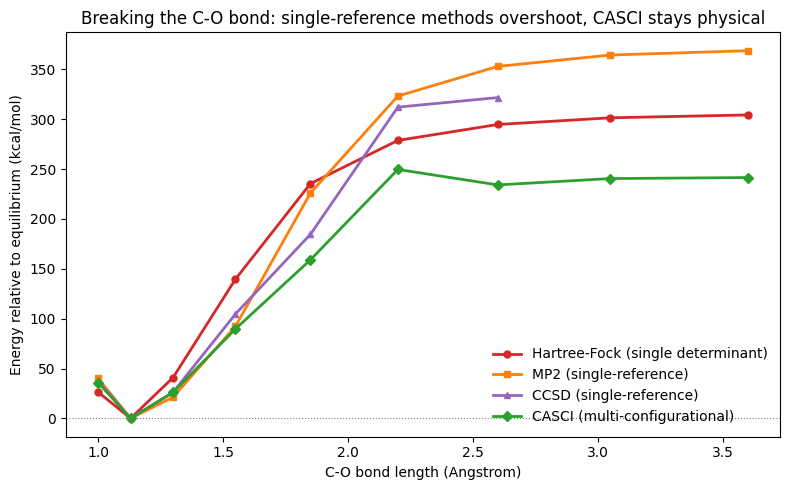

Gaps in the CCSD curve mark geometries where coupled cluster failed to converge.


In [5]:
ref = results.iloc[results["CASCI"].idxmin()]  # equilibrium reference (deepest CASCI point)

fig, ax = plt.subplots(figsize=(8, 5))
styles = {
    "HF":    ("Hartree-Fock (single determinant)", "o", "#d62728"),
    "MP2":   ("MP2 (single-reference)",            "s", "#ff7f0e"),
    "CCSD":  ("CCSD (single-reference)",           "^", "#9467bd"),
    "CASCI": ("CASCI (multi-configurational)",     "D", "#2ca02c"),
}
for col, (label, marker, color) in styles.items():
    rel = (results[col] - ref[col]) * HARTREE2KCAL
    ax.plot(results["r"], rel, marker=marker, color=color, label=label, lw=2, ms=5)

ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("C-O bond length (Angstrom)")
ax.set_ylabel("Energy relative to equilibrium (kcal/mol)")
ax.set_title("Breaking the C-O bond: single-reference methods overshoot, CASCI stays physical")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

print("Gaps in the CCSD curve mark geometries where coupled cluster failed to converge.")

## Why? Look inside the wavefunction

The diagnostic is the **leading-configuration weight**. If one configuration dominated (weight → 1), a single-reference method would be justified. For CO it starts near 1 at equilibrium — and then **collapses** as the bond breaks, dropping well below ½. That collapse is the precise reason the single-reference methods above fall apart.

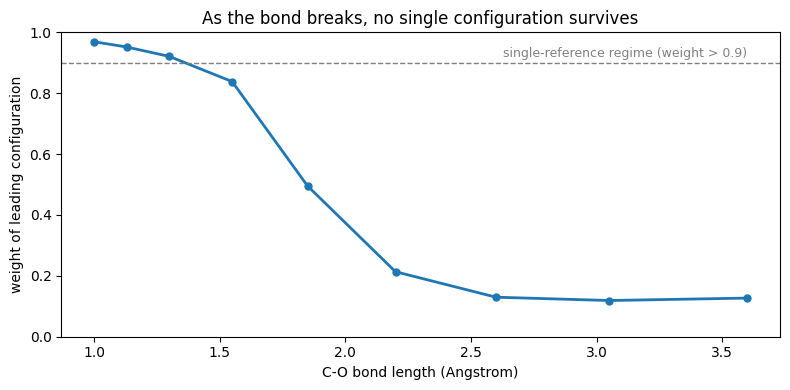

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results["r"], results["leading_weight"], "o-", color="#1f77b4", lw=2, ms=5)
ax.axhline(0.9, color="gray", ls="--", lw=1)
ax.text(results["r"].iloc[-1], 0.91, "single-reference regime (weight > 0.9)",
        ha="right", va="bottom", color="gray", fontsize=9)
ax.set_xlabel("C-O bond length (Angstrom)")
ax.set_ylabel("weight of leading configuration")
ax.set_title("As the bond breaks, no single configuration survives")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

### The physical picture at a stretched bond

At a stretched geometry the multi-configurational character is explicit: several determinants carry comparable weight. No single one can represent the wavefunction — which is exactly why the single-determinant methods fail here.

In [ ]:
structure_stretched = co_geometry(2.5)
with _silence_backends():
    scf_s = create("scf_solver")
    scf_s.settings().set("max_iterations", 300)
    _, wfn_hf_s = scf_s.run(
        structure_stretched, charge=0, spin_multiplicity=1, basis_or_guess=BASIS
    )
    active_s = create(
        "active_space_selector", "qdk_valence",
        num_active_electrons=ACTIVE_ELECTRONS, num_active_orbitals=ACTIVE_ORBITALS,
    ).run(wfn_hf_s)
    ham_s = create("hamiltonian_constructor").run(active_s.get_orbitals())
    na_s, nb_s = active_s.get_active_num_electrons()
    _, wfn_cas_s = create("multi_configuration_calculator", "macis_cas").run(ham_s, na_s, nb_s)

print("Leading configurations of stretched CO (occupations over the 8 active orbitals):\n")
for det, coeff in wfn_cas_s.get_top_determinants(max_determinants=6).items():
    print(f"  {det.to_string()[:ACTIVE_ORBITALS]}   weight = {abs(coeff) ** 2:6.1%}")